<a href="https://colab.research.google.com/github/WouterKroot/Normalization_NP/blob/main/Normalization_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scp

In [13]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

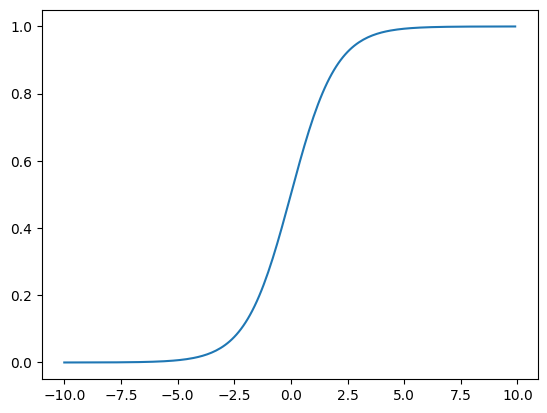

In [16]:
x = np.arange(-10, 10, 0.1)
y = sigmoid(x)

plt.plot(x, y)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

x_vals = np.linspace(-4, 4, 200)

def plot_pure_contrast_gain(A_S, sigma):
    # G_max blijft rotsvast op 1.0 omdat A_E meestijgt met A_S
    G_max = 1.0
    x_0 = np.log(sigma / A_S)

    R_baseline = 1.0 / (1.0 + np.exp(-x_vals)) # x_0 = 0 (bij A_S=1, sigma=1)
    R_attention = G_max / (1.0 + np.exp(-(x_vals - x_0)))

    plt.figure(figsize=(7, 4.5))
    plt.plot(x_vals, R_baseline, 'k--', label='Baseline')
    plt.plot(x_vals, R_attention, 'g-', linewidth=2, label=f'Contrast Gain Shift (x₀ = {x_0:.2f})')
    plt.title("Fig 1: Pure Contrast Gain (A_E = A_S)")
    plt.xlabel("Log-Contrast (x)")
    plt.ylabel("Respons (R)")
    plt.ylim(0, 2.5)
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_pure_contrast_gain,
         A_S=FloatSlider(min=1.0, max=4.0, step=0.1, value=2.0, description='A_E en A_S'),
         sigma=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description='Sigma (σ)'));


interactive(children=(FloatSlider(value=2.0, description='A_E en A_S', max=4.0, min=1.0), FloatSlider(value=1.…

In [29]:
def plot_pure_response_gain(A_E, sigma):
    # A_S blijft rotsvast op 1.0
    G_max = A_E / 1.0
    x_0 = np.log(sigma / 1.0)

    R_baseline = 1.0 / (1.0 + np.exp(-(x_vals - np.log(sigma))))
    R_attention = G_max / (1.0 + np.exp(-(x_vals - x_0)))

    plt.figure(figsize=(7, 4.5))
    plt.plot(x_vals, R_baseline, 'k--', label='Baseline')
    plt.plot(x_vals, R_attention, 'r-', linewidth=2, label=f'Response Gain (G_max = {G_max:.2f})')
    plt.title("Fig 2: Pure Response Gain (A_S = 1.0)")
    plt.xlabel("Log-Contrast (x)")
    plt.ylabel("Respons (R)")
    plt.ylim(0, 2.5)
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_pure_response_gain,
         A_E=FloatSlider(min=1.0, max=2.5, step=0.1, value=1.8, description='A_E (Piek)'),
         sigma=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, description='Sigma (σ)'));


interactive(children=(FloatSlider(value=1.8, description='A_E (Piek)', max=2.5, min=1.0), FloatSlider(value=1.…

In [30]:

theta_vals = np.linspace(-90, 90, 200)

def gaussian(theta, peak, width, baseline=1.0):
    return baseline + (peak - baseline) * np.exp(-0.5 * (theta / width)**2)

def plot_tuning_interaction(peak_A_e, width_A_e, peak_A_s, width_A_s, sigma, contrast):
    # Bereken de tuning profielen
    A_E = gaussian(theta_vals, peak_A_e, width_A_e, baseline=1.0)
    A_S = gaussian(theta_vals, peak_A_s, width_A_s, baseline=1.0)

    # Neuronale tuning drives (fixed)
    E_0 = contrast * gaussian(theta_vals, 1.0, 20.0, baseline=0.0)
    S_0 = contrast * gaussian(theta_vals, 1.0, 40.0, baseline=0.0)

    R_baseline = E_0 / (S_0 + sigma)
    R_attention = (A_E * E_0) / (A_S * S_0 + sigma)

    plt.figure(figsize=(8, 5))
    plt.plot(theta_vals, R_baseline, 'k--', label='Baseline')
    plt.plot(theta_vals, R_attention, 'b-', linewidth=2, label='Met Attentie')
    plt.title(f"Fig 3: Tuningcurve (Interactie van CG & RG bij Contrast = {contrast})")
    plt.xlabel("Oriëntatie (graden)")
    plt.ylabel("Neurale Respons R(θ)")
    plt.ylim(0, 1.2)
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_tuning_interaction,
         peak_A_e=FloatSlider(min=1.0, max=4.0, step=0.1, value=1.5, description='Piek A_e'),
         width_A_e=FloatSlider(min=5.0, max=90.0, step=1.0, value=5.0, description='Breedte A_e'),
         peak_A_s=FloatSlider(min=1.0, max=4.0, step=0.1, value=1.5, description='Piek A_s'),
         width_A_s=FloatSlider(min=5.0, max=90.0, step=1.0, value=15.0, description='Breedte A_s'),
         sigma=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.3, description='Sigma (σ)'),
         contrast=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.4, description='Contrast'));


interactive(children=(FloatSlider(value=1.5, description='Piek A_e', max=4.0, min=1.0), FloatSlider(value=5.0,…